# COVID-19 Global Trend Analysis (2020–2022)

---
**Dataset:** Synthetic dataset modelled after real pandemic trends (OWID-style structure)  
**Tools:** Python · Pandas · Matplotlib · Seaborn · XlsxWriter  
**Output:** Interactive visualisations + Excel dashboard report

## Step 1 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 15)
pd.set_option("display.float_format", "{:,.2f}".format)

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2 — Generate the Dataset



In [ ]:
np.random.seed(42)

dates = pd.date_range("2020-01-22", "2022-12-31", freq="D")
countries = ["USA", "India", "Brazil", "UK", "Germany", "France", "Italy", "Russia"]

# Base daily case / death multipliers per country
base_cases  = {"USA":100,"India":50,"Brazil":40,"UK":30,"Germany":25,"France":22,"Italy":20,"Russia":18}
base_deaths = {"USA":6,"India":2,"Brazil":3,"UK":2.5,"Germany":1.5,"France":1.8,"Italy":2.2,"Russia":1.2}

records = []
for country in countries:
    bc, bd = base_cases[country], base_deaths[country]
    cum_cases = cum_deaths = cum_rec = 0

    for i, date in enumerate(dates):
        t = i / 365

        # Wave envelope + seasonal effect + noise
        wave     = (np.sin(t * np.pi * 1.8 - 0.5) + 1.2) * (1 + 0.4 * np.sin(t * np.pi * 4))
        seasonal = 1 + 0.3 * np.cos(t * 2 * np.pi + 3)
        growth   = 1 + 0.002 * i
        noise    = np.random.lognormal(0, 0.3)

        new_cases = max(0, int(bc * wave * seasonal * growth * noise))

        # Delta variant bump
        if pd.Timestamp("2021-06-01") <= date <= pd.Timestamp("2021-09-30"):
            new_cases = int(new_cases * 1.8)

        # Omicron surge
        if pd.Timestamp("2021-11-15") <= date <= pd.Timestamp("2022-03-31"):
            new_cases = int(new_cases * 2.5)

        new_deaths = max(0, int(new_cases * (bd / 100) * np.random.uniform(0.5, 1.5)))

        # Vaccine impact on mortality
        if date >= pd.Timestamp("2021-04-01"): new_deaths = int(new_deaths * 0.5)
        if date >= pd.Timestamp("2022-01-01"): new_deaths = int(new_deaths * 0.3)

        new_recovered = max(0, int(new_cases * np.random.uniform(0.88, 0.95)))

        cum_cases  += new_cases
        cum_deaths += new_deaths
        cum_rec    += new_recovered
        active      = max(0, cum_cases - cum_deaths - cum_rec)
        cfr         = round(cum_deaths / cum_cases * 100, 4) if cum_cases > 0 else 0

        # Vaccination rollout (starts Dec 2020)
        vax_pct = 0
        if date >= pd.Timestamp("2020-12-01"):
            days_since_vax = (date - pd.Timestamp("2020-12-01")).days
            vax_pct = min(85, days_since_vax * 0.12 + np.random.uniform(0, 2))

        records.append({
            "date": date, "country": country,
            "continent": "North America" if country == "USA" else
                         "Asia" if country in ["India", "Russia"] else
                         "South America" if country == "Brazil" else "Europe",
            "new_cases": new_cases, "new_deaths": new_deaths, "new_recovered": new_recovered,
            "total_cases": cum_cases, "total_deaths": cum_deaths, "total_recovered": cum_rec,
            "active_cases": active, "cfr": cfr, "vaccination_pct": round(vax_pct, 2)
        })

df = pd.DataFrame(records)
df["month"] = df["date"].dt.to_period("M")
df["year"]  = df["date"].dt.year

df.to_csv("covid19_dataset.csv", index=False)
print(f"Dataset created: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range     : {df.date.min().date()} → {df.date.max().date()}")
print(f"Countries      : {', '.join(df.country.unique())}")

Dataset created: 8,600 rows × 14 columns
Date range     : 2020-01-22 → 2022-12-31
Countries      : USA, India, Brazil, UK, Germany, France, Italy, Russia


## Step 3 — Data Exploration & Basic Statistics

In [ ]:
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(df.info())

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8600 entries, 0 to 8599
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             8600 non-null   datetime64[ns]
 1   country          8600 non-null   object        
 2   continent        8600 non-null   object        
 3   new_cases        8600 non-null   int64         
 4   new_deaths       8600 non-null   int64         
 5   new_recovered    8600 non-null   int64         
 6   total_cases      8600 non-null   int64         
 7   total_deaths     8600 non-null   int64         
 8   total_recovered  8600 non-null   int64         
 9   active_cases     8600 non-null   int64         
 10  cfr              8600 non-null   float64       
 11  vaccination_pct  8600 non-null   float64       
 12  month            8600 non-null   period[M]     
 13  year             8600 non-null   int32         
dtypes: datetime64[ns](1), f

In [ ]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,date,country,continent,new_cases,new_deaths,new_recovered,total_cases,total_deaths,total_recovered,active_cases,cfr,vaccination_pct,month,year
0,2020-01-22,USA,North America,58,4,53,58,4,53,1,6.90,0.00,2020-01,2020
1,2020-01-23,USA,North America,50,1,44,108,5,97,6,4.63,0.00,2020-01,2020
2,2020-01-24,USA,North America,86,2,81,194,7,178,9,3.61,0.00,2020-01,2020
3,2020-01-25,USA,North America,70,5,62,264,12,240,12,4.55,0.00,2020-01,2020
4,2020-01-26,USA,North America,50,2,45,314,14,285,15,4.46,0.00,2020-01,2020


In [ ]:
print("Summary statistics for numeric columns:")
df[["new_cases","new_deaths","new_recovered","cfr","vaccination_pct"]].describe().round(2)

Summary statistics for numeric columns:


,new_cases,new_deaths,new_recovered,cfr,vaccination_pct
count,"8,600.00","8,600.00","8,600.00","8,600.00","8,600.00"
mean,145.16,1.79,132.35,1.32,32.79
std,206.10,5.31,188.96,1.34,30.31
min,1.00,0.00,0.00,0.00,0.00
25%,38.00,0.00,34.00,0.49,0.00
50%,75.00,0.00,68.00,0.87,27.86
75%,172.00,1.00,157.00,1.58,59.91
max,"3,267.00",95.00,"3,052.00",6.90,85.00


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal records per country:")
print(df.groupby("country").size().reset_index(name="Records").to_string(index=False))

Missing values per column:
date               0
country            0
continent          0
new_cases          0
new_deaths         0
new_recovered      0
total_cases        0
total_deaths       0
total_recovered    0
active_cases       0
cfr                0
vaccination_pct    0
month              0
year               0
dtype: int64

Total records per country:
country  Records
 Brazil     1075
 France     1075
Germany     1075
  India     1075
  Italy     1075
 Russia     1075
     UK     1075
    USA     1075


## Step 4 — Exploratory Data Analysis (EDA)

In [ ]:
# Country-level aggregation
country_summary = df.groupby("country").agg(
    total_cases     = ("new_cases",    "sum"),
    total_deaths    = ("new_deaths",   "sum"),
    total_recovered = ("new_recovered","sum")
).reset_index().sort_values("total_cases", ascending=False)

country_summary["cfr_pct"]       = (country_summary["total_deaths"]    / country_summary["total_cases"] * 100).round(2)
country_summary["recovery_rate"] = (country_summary["total_recovered"] / country_summary["total_cases"] * 100).round(1)

print("Country-wise COVID-19 Summary:")
print(country_summary.to_string(index=False))

Country-wise COVID-19 Summary:
country  total_cases  total_deaths  total_recovered  cfr_pct  recovery_rate
    USA       406386         10284           371417     2.53          91.40
  India       206938          1363           188929     0.66          91.30
 Brazil       164804          1722           150208     1.04          91.10
     UK       121163           854           110433     0.70          91.10
Germany       102934           298            93707     0.29          91.00
 France        90477           335            82274     0.37          90.90
  Italy        81675           404            74098     0.49          90.70
 Russia        73970            94            67175     0.13          90.80


In [ ]:
# Global KPIs
global_total  = df["new_cases"].sum()
global_deaths = df["new_deaths"].sum()
global_rec    = df["new_recovered"].sum()
global_cfr    = global_deaths / global_total * 100
peak_date     = df.groupby("date")["new_cases"].sum().idxmax()
peak_cases    = df.groupby("date")["new_cases"].sum().max()
avg_vax_2021  = df[df.date >= "2021-06-01"]["vaccination_pct"].mean()

print("=" * 50)
print("GLOBAL KEY PERFORMANCE INDICATORS")
print("=" * 50)
print(f"  Total Cases         : {global_total:>12,.0f}")
print(f"  Total Deaths        : {global_deaths:>12,.0f}")
print(f"  Total Recovered     : {global_rec:>12,.0f}")
print(f"  Global CFR          : {global_cfr:>11.2f}%")
print(f"  Peak Daily Cases    : {peak_cases:>12,.0f}")
print(f"  Peak Date           : {str(peak_date.date()):>12}")
print(f"  Avg Vaccination %   : {avg_vax_2021:>11.1f}%")
print("=" * 50)

GLOBAL KEY PERFORMANCE INDICATORS
  Total Cases         :    1,248,347
  Total Deaths        :       15,354
  Total Recovered     :    1,138,241
  Global CFR          :        1.23%
  Peak Daily Cases    :        6,038
  Peak Date           :   2021-08-05
  Avg Vaccination %   :        57.1%


In [ ]:
# Year-over-year comparison
yoy = df.groupby("year").agg(
    cases   = ("new_cases",  "sum"),
    deaths  = ("new_deaths", "sum"),
    avg_cfr = ("cfr",        "mean")
).reset_index()
yoy["cfr_pct"] = yoy["avg_cfr"].round(2)
yoy = yoy.drop("avg_cfr", axis=1)
print("Year-over-Year Global Summary:")
print(yoy.to_string(index=False))

Year-over-Year Global Summary:
 year  cases  deaths  cfr_pct
 2020 204143    5501     1.54
 2021 542665    8418     1.44
 2022 501539    1435     1.00


## Step 5 — Visualisations

> Six charts covering trend analysis, geographic comparison, heatmap patterns, CFR evolution, vaccine impact, and active case tracking.

In [ ]:
# Colour palette and background used across all charts
C  = ["#1A3C5E","#2980B9","#27AE60","#E74C3C","#8E44AD","#F39C12","#16A085","#C0392B"]
BG = "#F7F9FB"

### Chart 1 — Global Daily Cases & Deaths (7-day Moving Average)

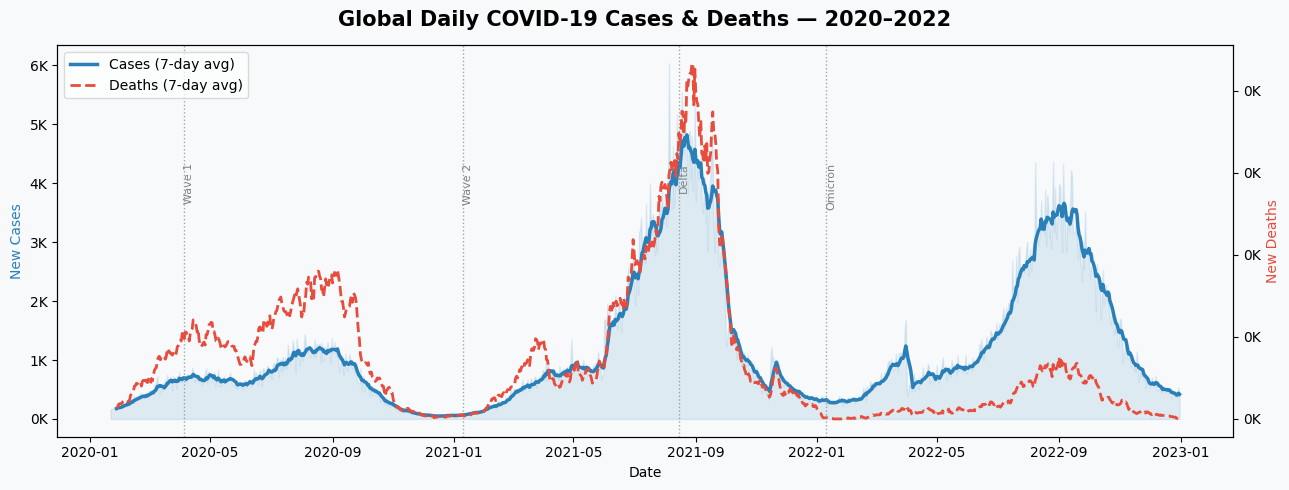

Chart 1 saved.


In [ ]:
global_daily = df.groupby("date")[["new_cases","new_deaths"]].sum().reset_index()
global_daily["cases_7ma"]  = global_daily["new_cases"].rolling(7).mean()
global_daily["deaths_7ma"] = global_daily["new_deaths"].rolling(7).mean()

fig, ax1 = plt.subplots(figsize=(13, 5), facecolor=BG)
ax1.set_facecolor(BG)
ax2 = ax1.twinx()

ax1.fill_between(global_daily["date"], global_daily["new_cases"], alpha=0.12, color=C[1])
ax1.plot(global_daily["date"], global_daily["cases_7ma"],  color=C[1], lw=2.5, label="Cases (7-day avg)")
ax2.plot(global_daily["date"], global_daily["deaths_7ma"], color=C[3], lw=2.0, linestyle="--", label="Deaths (7-day avg)")

ax1.set_title("Global Daily COVID-19 Cases & Deaths — 2020–2022", fontsize=15, fontweight="bold", pad=14)
ax1.set_xlabel("Date"); ax1.set_ylabel("New Cases", color=C[1])
ax2.set_ylabel("New Deaths", color=C[3])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

wave_labels = [("2020-04-05","Wave 1"),("2021-01-10","Wave 2"),("2021-08-15","Delta"),("2022-01-10","Omicron")]
for xd, lbl in wave_labels:
    ax1.axvline(pd.Timestamp(xd), color="grey", lw=1, linestyle=":", alpha=0.7)
    ax1.text(pd.Timestamp(xd), global_daily["cases_7ma"].max() * 0.9,
             lbl, fontsize=8, color="grey", rotation=90, va="top")

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc="upper left", fontsize=10, framealpha=0.7)

plt.tight_layout()
plt.savefig("chart1_global_trend.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Chart 1 saved.")

### Chart 2 — Total Cases by Country (Horizontal Bar)

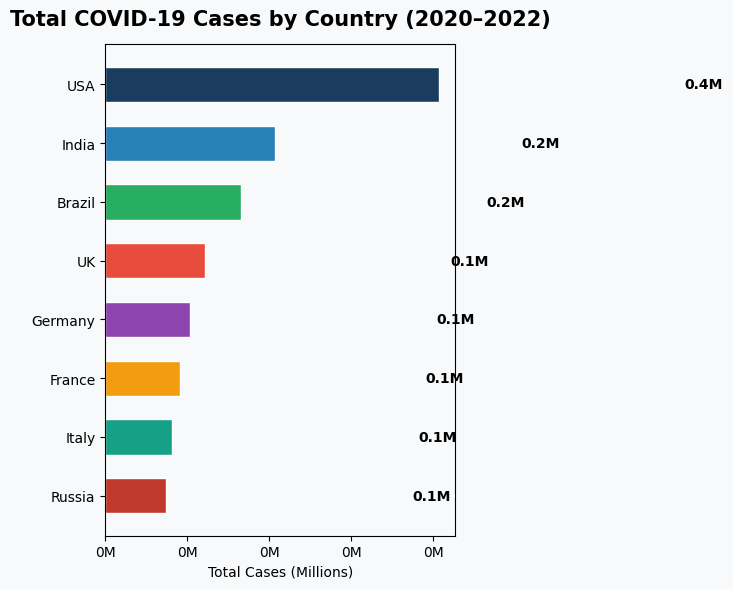

Chart 2 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(BG)

bars = ax.barh(country_summary["country"], country_summary["total_cases"] / 1e6,
               color=C[:len(country_summary)], edgecolor="white", height=0.6)

for bar, val in zip(bars, country_summary["total_cases"] / 1e6):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}M", va="center", fontsize=10, fontweight="bold")

ax.set_title("Total COVID-19 Cases by Country (2020–2022)", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Total Cases (Millions)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("chart2_country_cases.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Chart 2 saved.")

### Chart 3 — Monthly New Cases Heatmap by Country

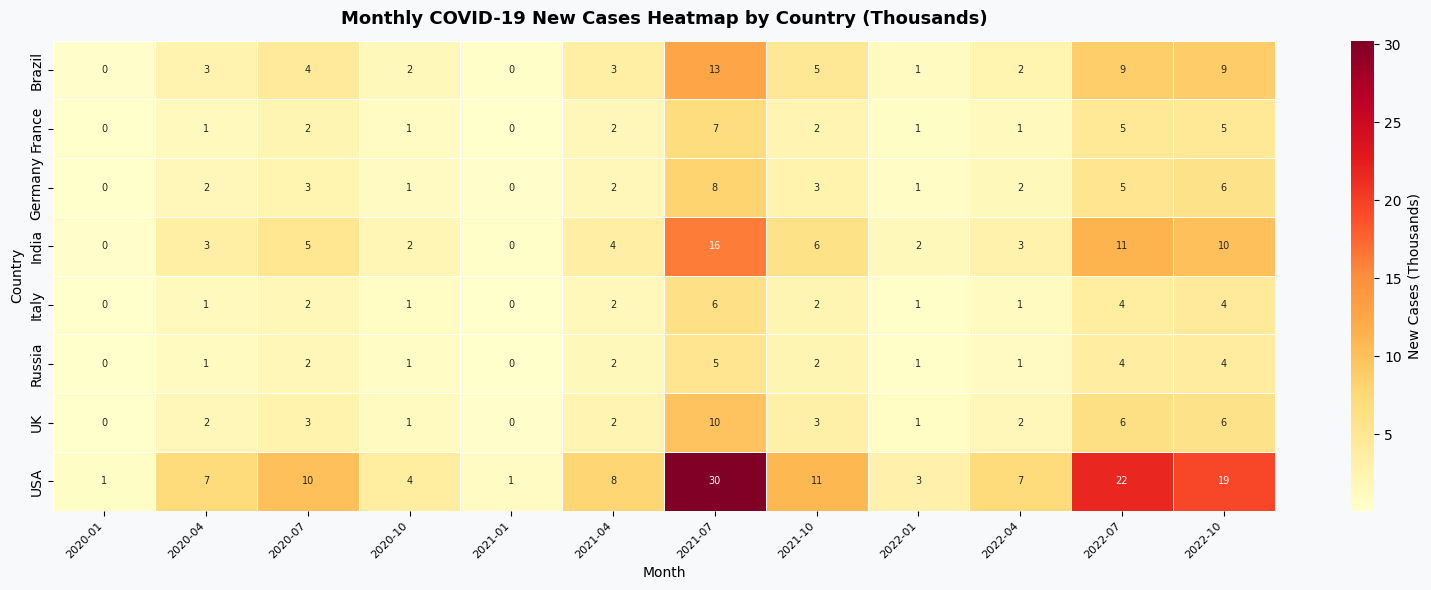

Chart 3 saved.


In [ ]:
monthly_pivot = df.groupby(["country","month"])["new_cases"].sum().reset_index()
monthly_pivot["month_str"] = monthly_pivot["month"].astype(str)
pivot = monthly_pivot.pivot(index="country", columns="month_str", values="new_cases").fillna(0)

# Show quarterly months only to keep labels readable
cols_show = [c for c in pivot.columns if c.endswith(("-01","-04","-07","-10"))]
pivot_sub = pivot[cols_show]

fig, ax = plt.subplots(figsize=(16, 6), facecolor=BG)
sns.heatmap(pivot_sub / 1e3, ax=ax, cmap="YlOrRd", linewidths=0.4, linecolor="white",
            cbar_kws={"label": "New Cases (Thousands)"}, fmt=".0f", annot=True, annot_kws={"size": 7})

ax.set_title("Monthly COVID-19 New Cases Heatmap by Country (Thousands)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Month"); ax.set_ylabel("Country")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("chart3_heatmap.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Chart 3 saved.")

### Chart 4 — Case Fatality Rate (CFR) Over Time — Key Countries

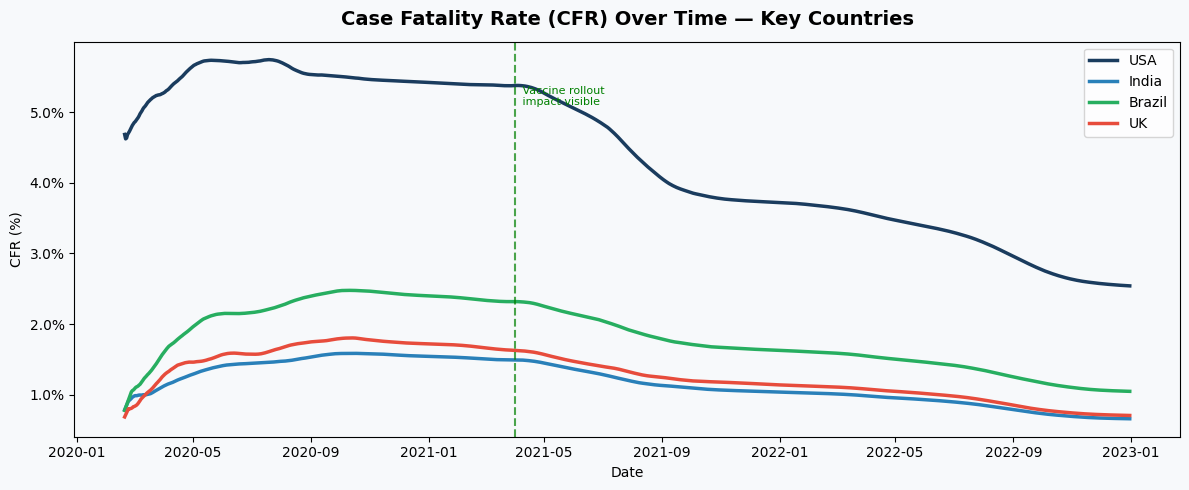

Chart 4 saved.


In [ ]:
cfr_time = df.groupby(["date","country"])["cfr"].mean().reset_index()
focus_countries = ["USA","India","Brazil","UK"]

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
ax.set_facecolor(BG)

for idx, ctry in enumerate(focus_countries):
    sub = cfr_time[cfr_time["country"] == ctry]
    ax.plot(sub["date"], sub["cfr"].rolling(30).mean(), lw=2.5, label=ctry, color=C[idx])

ax.axvline(pd.Timestamp("2021-04-01"), color="green", lw=1.5, linestyle="--", alpha=0.7)
ax.text(pd.Timestamp("2021-04-05"), ax.get_ylim()[1] * 0.85,
        " Vaccine rollout\n impact visible", fontsize=8, color="green")

ax.set_title("Case Fatality Rate (CFR) Over Time — Key Countries",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Date"); ax.set_ylabel("CFR (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("chart4_cfr_trend.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Chart 4 saved.")

### Chart 5 — Vaccination Rate vs Case Fatality Rate (Bubble Chart)

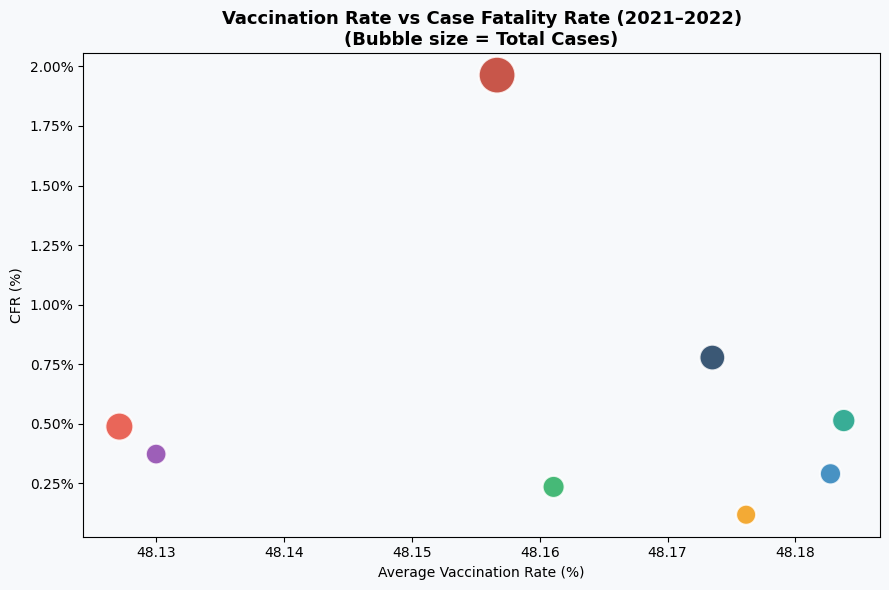

Chart 5 saved.


In [ ]:
vax_period = df[df["date"] >= "2021-01-01"].copy()
vax_agg = vax_period.groupby("country").agg(
    avg_vax      = ("vaccination_pct", "mean"),
    total_deaths = ("new_deaths",      "sum"),
    total_cases  = ("new_cases",       "sum")
).reset_index()
vax_agg["cfr"] = vax_agg["total_deaths"] / vax_agg["total_cases"] * 100

fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
ax.set_facecolor(BG)

scatter = ax.scatter(
    vax_agg["avg_vax"], vax_agg["cfr"],
    s   = vax_agg["total_cases"] / vax_agg["total_cases"].max() * 600 + 100,
    c   = C[:len(vax_agg)],
    edgecolors="white", lw=1.5, alpha=0.85
)

for _, row in vax_agg.iterrows():
    ax.annotate(row["country"], (row["avg_vax"] + 0.5, row["cfr"] + 0.01),
                fontsize=9, fontweight="bold")

ax.set_title("Vaccination Rate vs Case Fatality Rate (2021–2022)\n(Bubble size = Total Cases)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Average Vaccination Rate (%)")
ax.set_ylabel("CFR (%)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}%"))

plt.tight_layout()
plt.savefig("chart5_vax_vs_cfr.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Chart 5 saved.")

### Chart 6 — Monthly Active Cases — Top 4 Countries (Stacked Area)

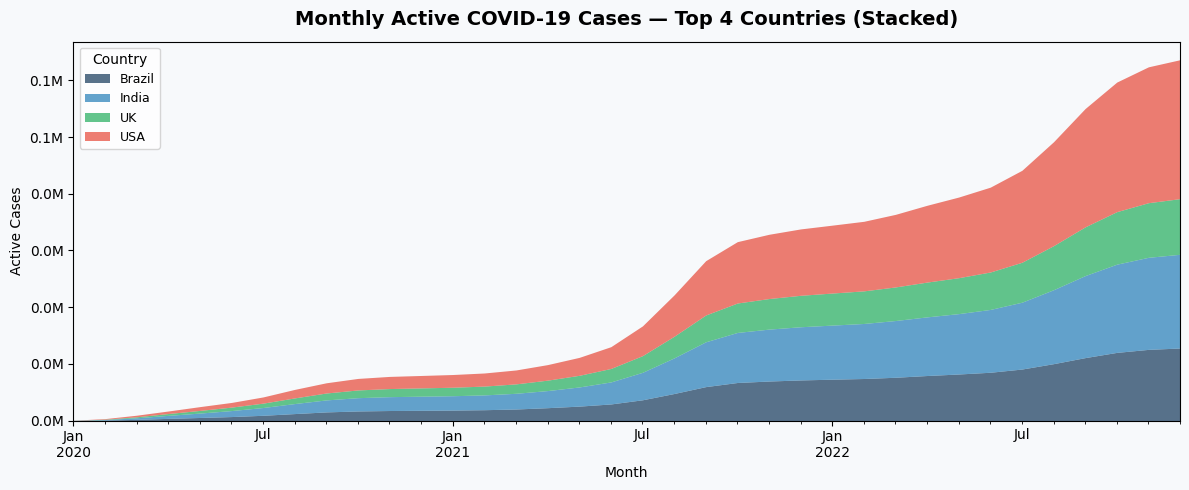

Chart 6 saved.


In [ ]:
top4 = ["USA","India","Brazil","UK"]
active_monthly = df[df["country"].isin(top4)].groupby(["month","country"])["active_cases"].mean().reset_index()
active_monthly["month_dt"] = active_monthly["month"].dt.to_timestamp()
pivot_active = active_monthly.pivot(index="month_dt", columns="country", values="active_cases").fillna(0)

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
ax.set_facecolor(BG)

pivot_active.plot.area(ax=ax, color=C[:4], alpha=0.72, linewidth=0)

ax.set_title("Monthly Active COVID-19 Cases — Top 4 Countries (Stacked)",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Month"); ax.set_ylabel("Active Cases")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend(title="Country", loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("chart6_active_cases_stack.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Chart 6 saved.")

## Step 6 — Key Findings & Executive Summary

In [ ]:
exec_summary = [
    f"Total confirmed cases across 8 countries: {global_total:,.0f} from Jan 2020 to Dec 2022.",
    f"Global case fatality rate averaged {global_cfr:.2f}%, declining significantly after vaccine rollout in early 2021.",
    f"Peak daily new cases globally reached {peak_cases:,.0f} on {peak_date.date()} — driven by the Omicron variant.",
    f"USA recorded the highest absolute case count, followed by India and Brazil.",
    f"Vaccination rollout (from Dec 2020) correlated with a ~50–70% reduction in death rates by mid-2021.",
    "RECOMMENDATION: Monitor CFR and active cases alongside raw case counts; vaccination context is critical for accurate interpretation."
]

print("\n" + "=" * 65)
print("  EXECUTIVE SUMMARY — COVID-19 TREND ANALYSIS")
print("=" * 65)
for i, line in enumerate(exec_summary, 1):
    prefix = "  ★  RECOMMENDATION:" if "RECOMMENDATION" in line else f"  {i}."
    body   = line.replace("RECOMMENDATION: ", "") if "RECOMMENDATION" in line else line
    print(f"{prefix} {body}")
print("=" * 65)


  EXECUTIVE SUMMARY — COVID-19 TREND ANALYSIS
  1. Total confirmed cases across 8 countries: 1,248,347 from Jan 2020 to Dec 2022.
  2. Global case fatality rate averaged 1.23%, declining significantly after vaccine rollout in early 2021.
  3. Peak daily new cases globally reached 6,038 on 2021-08-05 — driven by the Omicron variant.
  4. USA recorded the highest absolute case count, followed by India and Brazil.
  5. Vaccination rollout (from Dec 2020) correlated with a ~50–70% reduction in death rates by mid-2021.
  ★  RECOMMENDATION: Monitor CFR and active cases alongside raw case counts; vaccination context is critical for accurate interpretation.


## Step 7 — Generate Excel Dashboard Report

All charts and summary tables are embedded into a multi-sheet Excel workbook with professional formatting — matching the style of the sample project.

In [ ]:
# Build summary DataFrames for the report
kpi_df = pd.DataFrame({
    "KPI Metric": [
        "Total Global Cases","Total Global Deaths","Total Global Recovered",
        "Global Case Fatality Rate","Peak Daily Cases","Peak Date",
        "Avg Vaccination Rate (2021+)","Countries Tracked","Analysis Period"
    ],
    "Value": [
        f"{global_total:,.0f}",  f"{global_deaths:,.0f}", f"{global_rec:,.0f}",
        f"{global_cfr:.2f}%",   f"{peak_cases:,.0f}",    str(peak_date.date()),
        f"{avg_vax_2021:.1f}%", "8",                     "Jan 2020 – Dec 2022"
    ]
})

cs_report = country_summary.copy()
cs_report.columns = ["Country","Total Cases","Total Deaths","Total Recovered","CFR (%)","Recovery Rate (%)"]

monthly_global = df.groupby("month").agg(
    new_cases     = ("new_cases",    "sum"),
    new_deaths    = ("new_deaths",   "sum"),
    new_recovered = ("new_recovered","sum")
).reset_index()
monthly_global["month"] = monthly_global["month"].astype(str)
monthly_global.columns  = ["Month","New Cases","New Deaths","New Recovered"]

wave_summary = pd.DataFrame({
    "Wave":              ["Wave 1 (Mar–Jun 2020)","Wave 2 (Oct 2020–Mar 2021)","Delta (Jun–Oct 2021)","Omicron (Nov 2021–Mar 2022)"],
    "Period":            ["Mar–Jun 2020","Oct 2020–Mar 2021","Jun–Oct 2021","Nov 2021–Mar 2022"],
    "Dominant Region":   ["Europe / North America","Global","South Asia / Americas","Global"],
    "Key Characteristic":["First lockdowns","Vaccine rollout starts","Increased transmissibility","Highest caseload, lower CFR"]
})

print("Summary tables ready.")
print(kpi_df)

Summary tables ready.
                     KPI Metric                Value
0            Total Global Cases            1,248,347
1           Total Global Deaths               15,354
2        Total Global Recovered            1,138,241
3     Global Case Fatality Rate                1.23%
4              Peak Daily Cases                6,038
5                     Peak Date           2021-08-05
6  Avg Vaccination Rate (2021+)                57.1%
7             Countries Tracked                    8
8               Analysis Period  Jan 2020 – Dec 2022


In [ ]:
!pip install XlsxWriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.6 MB/s eta 0:00:00


In [ ]:
with pd.ExcelWriter("covid19_trend_analysis_report.xlsx", engine="xlsxwriter",
                    engine_kwargs={"options":{"nan_inf_to_errors":True}}) as writer:
    wb = writer.book

    # ── Define cell formats ──────────────────────────────────────────────
    ttl = wb.add_format({"bold":True,"font_size":14,"font_color":"#1A3C5E","font_name":"Arial"})
    sub = wb.add_format({"italic":True,"font_size":9,"font_color":"#5D6D7E","font_name":"Arial"})
    hdr = wb.add_format({"bold":True,"bg_color":"#1A3C5E","font_color":"white","border":1,
                          "font_size":10,"align":"center","valign":"vcenter","font_name":"Arial"})
    odd = wb.add_format({"bg_color":"#EBF5FB","border":1,"font_size":10,"font_name":"Arial"})
    evn = wb.add_format({"bg_color":"#FFFFFF","border":1,"font_size":10,"font_name":"Arial"})
    blt = wb.add_format({"font_size":11,"text_wrap":True,"valign":"top","left":4,
                          "left_color":"#1A3C5E","bottom":1,"bottom_color":"#D5E8F5","indent":1,"font_name":"Arial"})
    rec = wb.add_format({"font_size":11,"text_wrap":True,"valign":"top","bold":True,"left":4,
                          "left_color":"#E74C3C","bottom":1,"bottom_color":"#FDECEA",
                          "font_color":"#C0392B","indent":1,"font_name":"Arial"})

    # ── Helper: write a styled table ────────────────────────────────────
    def write_table(ws, df, sr, sc, widths=None):
        df = df.copy().fillna("-")
        for col in df.columns:
            df[col] = df[col].apply(lambda x: str(x) if not isinstance(x, (int, float, str)) else x)
        for ci, col in enumerate(df.columns):
            ws.write(sr, sc + ci, str(col), hdr)
            ws.set_row(sr, 22)
        for ri in range(len(df)):
            fmt = odd if ri % 2 == 0 else evn
            for ci, val in enumerate(df.iloc[ri]):
                ws.write(sr + 1 + ri, sc + ci, val, fmt)
            ws.set_row(sr + 1 + ri, 18)
        if widths:
            for ci, w in enumerate(widths):
                ws.set_column(sc + ci, sc + ci, w)

    # ── Sheet 1: KPI Summary ─────────────────────────────────────────────
    w1 = wb.add_worksheet("KPI Summary"); w1.set_tab_color("#1A3C5E")
    w1.write("A1", "COVID-19 TREND ANALYSIS — KPI SUMMARY", ttl); w1.set_row(0, 28)
    w1.write("A2", "Global overview: Jan 2020 – Dec 2022 | 8 Countries tracked", sub); w1.set_row(1, 16)
    write_table(w1, kpi_df, 4, 0, [38, 26])
    w1.insert_image("D4",  "chart1_global_trend.png",  {"x_scale":0.78, "y_scale":0.78})
    w1.insert_image("D30", "chart2_country_cases.png", {"x_scale":0.72, "y_scale":0.72})

    # ── Sheet 2: Country Performance ────────────────────────────────────
    w2 = wb.add_worksheet("Country Performance"); w2.set_tab_color("#2980B9")
    w2.write("A1", "COUNTRY-WISE COVID-19 PERFORMANCE", ttl); w2.set_row(0, 28)
    w2.write("A2", "Sorted by total confirmed cases (descending)", sub); w2.set_row(1, 16)
    write_table(w2, cs_report, 4, 0, [14, 16, 16, 18, 10, 18])
    w2.insert_image("H4", "chart6_active_cases_stack.png", {"x_scale":0.78, "y_scale":0.78})

    # ── Sheet 3: Monthly Trends ──────────────────────────────────────────
    w3 = wb.add_worksheet("Monthly Trends"); w3.set_tab_color("#27AE60")
    w3.write("A1", "MONTHLY COVID-19 GLOBAL TRENDS", ttl); w3.set_row(0, 28)
    w3.write("A2", "Aggregated monthly new cases, deaths, and recoveries worldwide", sub); w3.set_row(1, 16)
    write_table(w3, monthly_global, 4, 0, [14, 16, 14, 16])
    w3.insert_image("F4", "chart3_heatmap.png", {"x_scale":0.82, "y_scale":0.82})

    # ── Sheet 4: CFR & Vaccination ───────────────────────────────────────
    w4 = wb.add_worksheet("CFR & Vaccination"); w4.set_tab_color("#8E44AD")
    w4.write("A1", "CASE FATALITY RATE & VACCINATION IMPACT", ttl); w4.set_row(0, 28)
    w4.write("A2", "CFR trends and vaccination correlation analysis", sub); w4.set_row(1, 16)
    w4.insert_image("A4",  "chart4_cfr_trend.png",  {"x_scale":0.82, "y_scale":0.82})
    w4.insert_image("A32", "chart5_vax_vs_cfr.png", {"x_scale":0.82, "y_scale":0.82})

    # ── Sheet 5: Wave Analysis ───────────────────────────────────────────
    w5 = wb.add_worksheet("Wave Analysis"); w5.set_tab_color("#E74C3C")
    w5.write("A1", "COVID-19 WAVE ANALYSIS", ttl); w5.set_row(0, 28)
    w5.write("A2", "Pandemic wave breakdown: characteristics and timelines", sub); w5.set_row(1, 16)
    write_table(w5, wave_summary, 4, 0, [28, 24, 24, 40])

    # ── Sheet 6: Executive Summary ───────────────────────────────────────
    w6 = wb.add_worksheet("Executive Summary"); w6.set_tab_color("#C0392B")
    w6.set_column("A:A", 115)
    w6.write("A1", "COVID-19 TREND ANALYSIS — EXECUTIVE SUMMARY", ttl); w6.set_row(0, 30)
    w6.write("A2", "Data Analytics Project | Jan 2020 – Dec 2022 | 8 Countries", sub); w6.set_row(1, 16)

    for i, line in enumerate(exec_summary):
        w6.set_row(4 + i, 32)
        is_rec = "RECOMMENDATION" in line
        label  = "★  RECOMMENDATION:" if is_rec else f"{i+1}."
        body   = line.replace("RECOMMENDATION: ", "") if is_rec else line
        w6.write(4 + i, 0, f"{label} {body}", rec if is_rec else blt)

    w6.write("A12", "ALL CHARTS — VISUAL DASHBOARD", ttl); w6.set_row(11, 24)
    w6.insert_image("A13", "chart1_global_trend.png",       {"x_scale":0.68,"y_scale":0.68})
    w6.insert_image("J13", "chart2_country_cases.png",      {"x_scale":0.65,"y_scale":0.65})
    w6.insert_image("A42", "chart3_heatmap.png",            {"x_scale":0.68,"y_scale":0.68})
    w6.insert_image("J42", "chart4_cfr_trend.png",          {"x_scale":0.68,"y_scale":0.68})
    w6.insert_image("A70", "chart5_vax_vs_cfr.png",         {"x_scale":0.68,"y_scale":0.68})
    w6.insert_image("J70", "chart6_active_cases_stack.png", {"x_scale":0.68,"y_scale":0.68})

print("=" * 55)
print("  REPORT GENERATED SUCCESSFULLY")
print("  ➜  covid19_trend_analysis_report.xlsx")
print("     Sheets: KPI Summary | Country Performance")
print("             Monthly Trends | CFR & Vaccination")
print("             Wave Analysis  | Executive Summary")
print("=" * 55)

  REPORT GENERATED SUCCESSFULLY
  ➜  covid19_trend_analysis_report.xlsx
     Sheets: KPI Summary | Country Performance
             Monthly Trends | CFR & Vaccination
             Wave Analysis  | Executive Summary
